In [4]:
import pandas as pd
import yfinance as yf
from datetime import datetime  # Ensure this is imported
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pytz
import statsmodels.api as sm

In [5]:
start_date = datetime(2020, 1, 1)
end_date = datetime(2024, 12, 3)
stock_symbol = 'PANW'

# Fetch stock data from Yahoo Finance
stock = yf.download(stock_symbol, start=start_date, end=end_date)

# Debugging: Check if stock data is loaded correctly
if stock.empty:
    raise ValueError("Stock data could not be fetched. Please check the stock symbol or internet connection.")

[*********************100%***********************]  1 of 1 completed


In [20]:
# Convert stock index to timezone-aware (UTC)
#stock.index = stock.index.tz_localize('UTC')

# Make start timezone-aware (UTC)
start = pd.Timestamp('2021-04-03', tz=pytz.UTC)

win = 60
horizon = 1

# Define a target start date for training (timezone-naive)
#start = pd.Timestamp('2023-04-03')

if start not in stock.index:
    # Find the nearest date if 'start' does not exist in stock index
    start = stock.index.asof(start)

# Find the index of the start date in the stock data
try:
    train_start = stock.index.get_loc(start)
except KeyError:
    raise ValueError(f"The specified start date {start} is not present in the stock data index.")

position = 100

# Initialize dictionaries to store results
y_pred_xgb, y_test_xgb = {}, {}
signal_xgb, gain_loss_xgb, balance_xgb = {}, {}, {}
balance_xgb[train_start] = stock['Close'].iloc[train_start] * position

In [21]:
# Load macro-finance features from CSV file
feature_macro = pd.read_csv('Downloads/6105_final_selected_price_features.csv', index_col=0)

# Handle length mismatch between feature_macro and stock data
if len(feature_macro) != len(stock):
    print(f"Length mismatch: feature_macro has {len(feature_macro)} rows, stock has {len(stock)} rows.")
    # Trim or align feature_macro to match stock length
    feature_macro = feature_macro.iloc[:len(stock)]

# Shift data to avoid lookahead bias and backfill missing values
feature_macro = feature_macro.shift(1).bfill()

# Align features with stock data index (ensure they match)
feature_macro = feature_macro.set_index(stock.index)

# Prepare features dataset for modeling
features = feature_macro.reset_index(drop=True)

# Debugging: Check if features are aligned correctly
print(features.head())
print(f"Features shape: {features.shape}, Stock shape: {stock.shape}")

# # prepare macro-finance features
# feature_macro = pd.read_csv('Downloads/INFO6105_FeatureMart.csv', index_col = [0])
# feature_macro = feature_macro.drop(columns=['Date'])
# feature_macro = feature_macro.shift(1).fillna(method='bfill')
# feature_macro = feature_macro.set_index(stock.index)

# # merge your self-engineered features with macro_finance factors
# # Front filling would fill the missing values with the nearest non-missing values before them:
# features = feature_macro
# features.reset_index(drop=True, inplace=True)

Length mismatch: feature_macro has 1239 rows, stock has 1238 rows.
   avg_sell_price_tick  price_high_b  avg_sell_price_wrds  avg_price_m  \
0           234.932484      234.0000           234.943028   234.950166   
1           234.932484      234.0000           234.943028   234.950166   
2           235.935484      235.0000           235.932467   235.968743   
3           238.821808      238.6502           238.850379   238.856095   
4           241.545489      242.2000           241.553137   241.570967   

   avg_buy_price_Retail  price_high_m  avg_buy_price_Inst20k  \
0            234.938682        235.94             234.943330   
1            234.938682        235.94             234.943330   
2            235.958829        237.00             235.978114   
3            238.772184        240.54             238.785646   
4            241.549890        242.53             241.585459   

   avg_buy_price_Inst50k  avg_buy_price_LR  BestBidDepth_Share_tw  
0             234.942602        234

In [22]:
print(feature_macro.columns)

Index(['avg_sell_price_tick', 'price_high_b', 'avg_sell_price_wrds',
       'avg_price_m', 'avg_buy_price_Retail', 'price_high_m',
       'avg_buy_price_Inst20k', 'avg_buy_price_Inst50k', 'avg_buy_price_LR',
       'BestBidDepth_Share_tw'],
      dtype='object')


In [23]:
# Iterate from the first trading day in 2023 to the last day
for today in range(train_start, len(features) - 1):  # Use range to avoid ambiguous indexing
    yesterday = today - 1
    tomorrow = today + 1
    
    # Retrieve data for the past win days until yesterday
    X_train = features.iloc[today - win : today]  # lag values (today not included)
    y_train = stock['Close'].iloc[today - win : today]  # lead values (today not included)
    
    # Train XGBoost model
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, learning_rate=0.1)
    xgb_model.fit(X_train, y_train)
    
    # Make predictions on today's data
    X_test = features.iloc[today].values.reshape(1, -1)  # reshape for a single sample
    prediction = xgb_model.predict(X_test)
    y_pred_xgb[today] = float(prediction[0])  # Ensure it's a scalar

    # Safely extract scalar value for y_test_xgb
    y_test_value = stock['Open'].iloc[today]
    if isinstance(y_test_value, pd.Series):  # Handle edge case where it's a Series
        y_test_value = y_test_value.iloc[0]
    y_test_xgb[today] = float(y_test_value)  # Ensure it's a scalar

    # Debugging: Print values before comparison
    #print(f"y_pred_xgb[{today}]: {y_pred_xgb[today]}, y_test_xgb[{today}]: {y_test_xgb[today]}")

    # Day trade gain or loss based on predictions
    if y_pred_xgb[today] >= y_test_xgb[today]:
        signal_xgb[today] = 1
        gain_loss_xgb[today] = -position * stock['Open'].iloc[today] + position * stock['Close'].iloc[today]
    else:
        signal_xgb[today] = -1
        gain_loss_xgb[today] = position * stock['Open'].iloc[today] - position * stock['Close'].iloc[today]
    
    # Update account balance
    balance_xgb[tomorrow] = balance_xgb.get(today, 0) + gain_loss_xgb[today]

In [24]:
# Convert results into DataFrames for analysis
signal_xgb = pd.DataFrame.from_dict(signal_xgb, orient='index', columns=['signal'])
gain_loss_xgb = pd.DataFrame.from_dict(gain_loss_xgb, orient='index', columns=['gain_loss'])
balance_xgb = pd.DataFrame.from_dict(balance_xgb, orient='index', columns=['balance_xgb'])
y_pred_xgb = pd.DataFrame.from_dict(y_pred_xgb, orient='index', columns=['y_pred'])
y_test_xgb = pd.DataFrame.from_dict(y_test_xgb, orient='index', columns=['y_test'])


In [25]:
# Concatenate results along columns axis
results_xgb = pd.concat([signal_xgb, gain_loss_xgb, balance_xgb, y_pred_xgb, y_test_xgb], axis=1)
results_xgb['Date'] = stock.index[results_xgb.index]

# Set 'Date' as index and calculate buy-and-hold strategy for comparison
results_xgb.set_index('Date', inplace=True)
results_xgb['buy_hold'] = stock['Close'].loc[results_xgb.index] * position


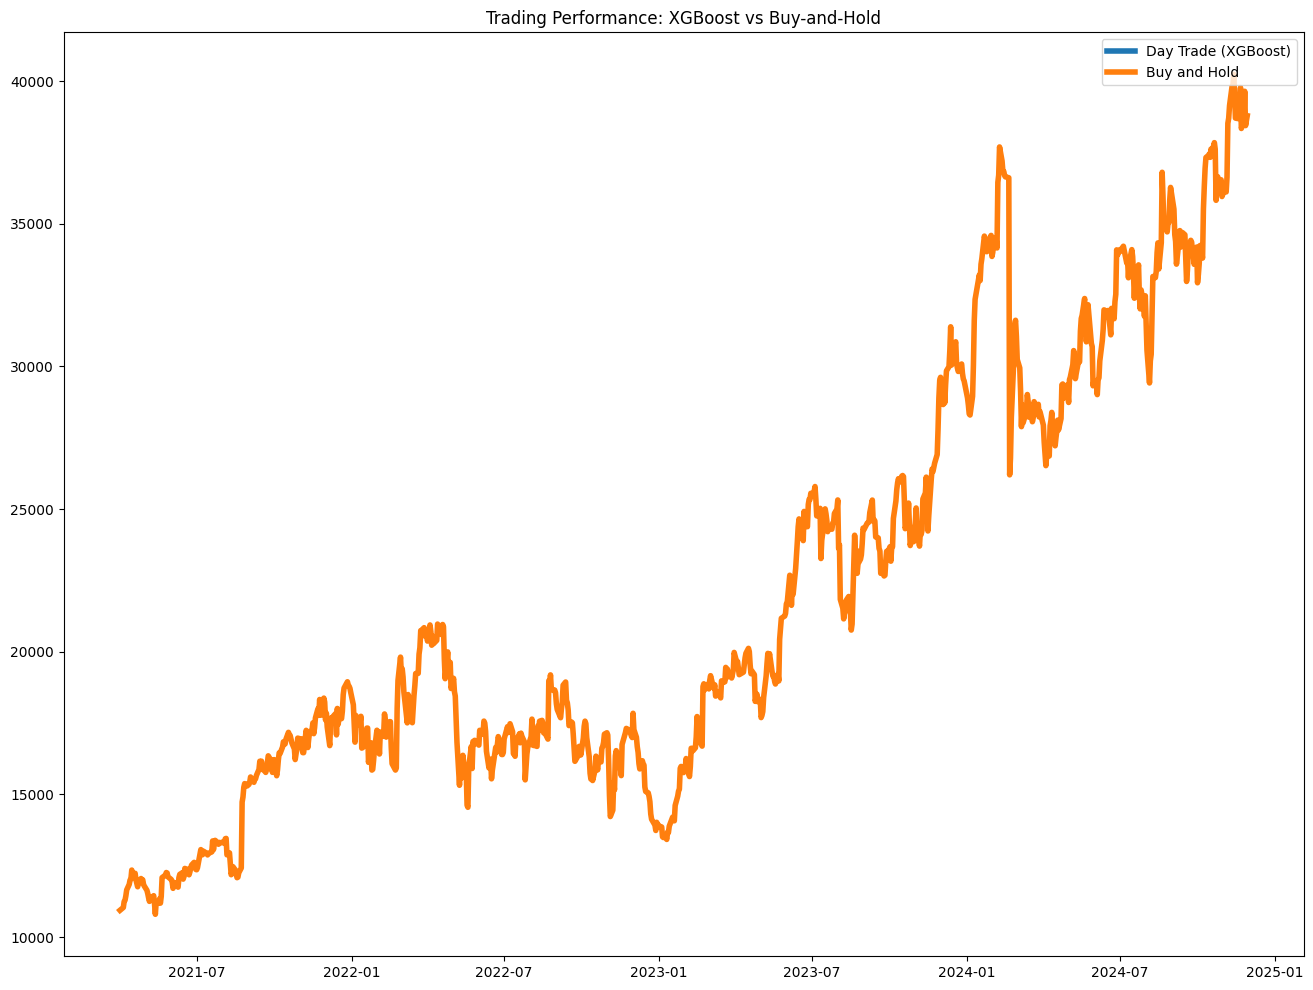

In [26]:
# Plot performance: Day Trade vs Buy-and-Hold
plt.figure(figsize=(16, 12))
plt.plot(results_xgb['balance_xgb'], linewidth=4, linestyle='solid', label='Day Trade (XGBoost)')
plt.plot(results_xgb['buy_hold'], linewidth=4, linestyle='solid', label='Buy and Hold')
plt.legend(loc="upper right")
plt.title("Trading Performance: XGBoost vs Buy-and-Hold")
plt.show()


In [28]:
# Model Configuration 
print(f"Model Configuration: window = {win} days, starting date = {start}")
print("------------------------------------------------------------------------------------------------")
# Prediction performance:
rmse = np.sqrt(np.mean((results_xgb['y_pred']-results_xgb['y_test'])**2))
print(f"Root-Mean-Squared-Error (RMSE) {start_date} to {end_date} is {rmse*100:.2f}%.")

# PnL by positions: long vs short
total_PnL = results_xgb['gain_loss'].sum()
holding_period_return = (results_xgb['balance_xgb'][-1]-results_xgb['balance_xgb'][0])/results_xgb['balance_xgb'][0]
print(f"The total PnL from {start} to {end_date} is: ${total_PnL:.2f}")
print(f"The total trading return from {start} to {end_date} is: {holding_period_return*100:.2f}%")

Model Configuration: window = 60 days, starting date = 2021-04-01 00:00:00+00:00
------------------------------------------------------------------------------------------------
Root-Mean-Squared-Error (RMSE) 2020-01-01 00:00:00 to 2024-12-03 00:00:00 is 616.00%.
The total PnL from 2021-04-01 00:00:00+00:00 to 2024-12-03 00:00:00 is: $0.00
The total trading return from 2021-04-01 00:00:00+00:00 to 2024-12-03 00:00:00 is: nan%


/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_66630/4168162825.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  holding_period_return = (results_xgb['balance_xgb'][-1]-results_xgb['balance_xgb'][0])/results_xgb['balance_xgb'][0]
